In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from datasets import Dataset, DatasetDict
from transformers import T5Tokenizer, T5ForConditionalGeneration, TrainingArguments, Trainer, DataCollatorForSeq2Seq
import torch
import wandb
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def prepare_grouped_dataset(jsonl_path, train_size=0.8, val_size=0.1):
    df = pd.read_json(jsonl_path, lines=True)

    # --- MULTIMODAL: Atomicity filter - discard incomplete groups ---
    df = df.groupby('group_id').filter(
        lambda g: g['title'].notna().all() and g['img_text'].notna().all()
                  and len(g) == 2
    ).reset_index(drop=True)
    # --- END MULTIMODAL ---

    # Mapeo senior: IA -> positive, Humano -> negative
    df['target_text'] = df['is_real'].map({0: "positive", 1: "negative"})
    df['input_text'] = "classify authenticity: " + df['title'] + " [SEP] " + df['img_text']

    # 1. Separar Test set (Hold-out)
    gs_test = GroupShuffleSplit(n_splits=1, train_size=train_size + val_size, random_state=42)
    train_val_idx, test_idx = next(gs_test.split(df, groups=df['group_id']))

    df_train_val = df.iloc[train_val_idx]
    df_test = df.iloc[test_idx]

    # 2. Separar Train y Eval del resto
    relative_train_size = train_size / (train_size + val_size)
    gs_eval = GroupShuffleSplit(n_splits=1, train_size=relative_train_size, random_state=42)
    train_idx, eval_idx = next(gs_eval.split(df_train_val, groups=df_train_val['group_id']))

    df_train = df_train_val.iloc[train_idx]
    df_eval = df_train_val.iloc[eval_idx]

    ds_dict = DatasetDict({
        'train': Dataset.from_pandas(df_train),
        'validation': Dataset.from_pandas(df_eval),
        'test': Dataset.from_pandas(df_test)
    })

    return ds_dict


In [4]:
model_name = "google-t5/t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)

ds_dict = prepare_grouped_dataset("/content/drive/MyDrive/TFG/titles_img_data.jsonl")

def tokenize_fn(examples):
    inputs = tokenizer(examples["input_text"], max_length=256, truncation=True, padding="max_length")
    targets = tokenizer(text_target=examples["target_text"], max_length=10, truncation=True, padding="max_length")
    inputs["labels"] = targets["input_ids"]
    return inputs

tokenized_dataset = ds_dict.map(tokenize_fn, batched=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1402 [00:00<?, ? examples/s]

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

In [5]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # En T5, los logits suelen ser una tupla, tomamos la primera parte
    predictions = np.argmax(logits[0], axis=-1)

    pos_label_id = tokenizer.encode("positive")[0]
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels.flatten(), predictions.flatten(), average='macro', pos_label=pos_label_id, zero_division=0
    )

    return {
        'accuracy': accuracy_score(labels.flatten(), predictions.flatten()),
        'f1_positive': f1,
        'precision_positive': precision,
        'recall_positive': recall
    }

def get_sentinel_prediction(text, model, tokenizer):
    input_ids = tokenizer("classify authenticity: " + text, return_tensors="pt").input_ids.to("cuda")

    with torch.no_grad():
        outputs = model(input_ids=input_ids, decoder_input_ids=torch.tensor([[tokenizer.pad_token_id]]).to("cuda"))
        logits = outputs.logits[:, 0, :]

    pos_id = tokenizer.encode("positive")[0]
    neg_id = tokenizer.encode("negative")[0]

    probs = torch.softmax(logits[:, [pos_id, neg_id]], dim=-1)
    return "IA" if probs[0][0] > probs[0][1] else "Humano"

def evaluate_model(model, tokenizer, dataset):
    predictions = []
    true_labels = []

    for example in dataset:
        predicted_label = get_sentinel_prediction(example['input_text'].replace('classify authenticity: ', ''), model, tokenizer)
        predictions.append(predicted_label)
        true_labels.append(example['target_text'])

    mapped_predictions = ["positive" if p == "IA" else "negative" for p in predictions]

    print("\n--- Resultados de Evaluación ---")
    accuracy = accuracy_score(true_labels, mapped_predictions)
    print(f"Accuracy: {accuracy:.4f}")

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, mapped_predictions, average=None, labels=['positive', 'negative'], zero_division=0
    )

    print("\nMétricas por clase:")
    print(f"  Clase 'positive' (IA):\n    Precision: {precision[0]:.4f}\n    Recall:    {recall[0]:.4f}\n    F1-score:  {f1[0]:.4f}")
    print(f"  Clase 'negative' (Humano):\n    Precision: {precision[1]:.4f}\n    Recall:    {recall[1]:.4f}\n    F1-score:  {f1[1]:.4f}")

    return true_labels, mapped_predictions

def plot_confusion_matrix(y_true, y_pred):
    labels = ['positive', 'negative']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['IA (Synthetic)', 'Humano (Real)'],
                yticklabels=['IA (Synthetic)', 'Humano (Real)'])

    plt.title('Matriz de Confusión: T5 Sentinel - Titulares', fontsize=14)
    plt.xlabel('Predicción del Modelo', fontsize=12)
    plt.ylabel('Etiqueta Real', fontsize=12)

    plt.savefig('matriz_confusion_t5.png', dpi=300, bbox_inches='tight')
    plt.show()


In [6]:
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'eval/f1_positive',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'distribution': 'log_uniform_values',
            'min': 1e-6,
            'max': 1e-4
        },
        'batch_size': {
            'values': [8, 16, 32]
        },
        'grad_acc': {
            'values': [2, 4, 8]
        },
        'epochs': {
            'value': 5
        },
        'weight_decay': {
            'values': [0.0, 0.01, 0.1]
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project="TFG-T5-Detector-img")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: dyayo2lt
Sweep URL: https://wandb.ai/javierprior04-universidad-de-murcia/TFG-T5-Detector-img/sweeps/dyayo2lt


In [7]:
def train_sweep():
    with wandb.init(config={"image_context": True}) as run:
        config = wandb.config

        # Instantiate fresh model for each run
        model = T5ForConditionalGeneration.from_pretrained(model_name)
        data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

        training_args = TrainingArguments(
            output_dir="./temp_results",
            learning_rate=config.learning_rate,
            per_device_train_batch_size=config.batch_size,
            gradient_accumulation_steps=config.grad_acc,
            num_train_epochs=config.epochs,
            weight_decay=config.weight_decay,
            eval_strategy="epoch",
            report_to="wandb",
            fp16=True
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_dataset["train"],
            eval_dataset=tokenized_dataset["validation"],
            data_collator=data_collator,
            compute_metrics=compute_metrics
        )

        trainer.train()


In [8]:
# Ejecutar el sweep (ajusta count según los recursos de Colab que tengas disponibles)
wandb.agent(sweep_id, function=train_sweep, count=5)


wandb: Agent Starting Run: 9iqguvpq with config:
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	grad_acc: 8
wandb: 	learning_rate: 3.388945511418763e-06
wandb: 	weight_decay: 0.1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: javierprior04 (javierprior04-universidad-de-murcia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Positive,Precision Positive,Recall Positive
1,No log,1.145975,0.796591,0.119833,0.123073,0.116921
2,No log,0.083139,0.954545,0.619891,0.621813,0.618182
3,No log,0.069470,0.958523,0.792070,0.793064,0.792614
4,No log,0.066834,0.961932,0.809160,0.810290,0.809659
5,No log,0.065509,0.961932,0.809604,0.809729,0.809659


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 1465) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 1465) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 1465) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 1465) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] t

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 1465) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


eval/accuracy,▁████
eval/f1_positive,▁▆███
eval/loss,█▁▁▁▁
eval/precision_positive,▁▆███
eval/recall_positive,▁▆███
eval/runtime,█▂▁▁▁
eval/samples_per_second,▁▇███
eval/steps_per_second,▁▇███
train/epoch,▁▃▅▆██
train/global_step,▁▃▅▆██
eval/accuracy,0.96193


In [13]:
import wandb

# Asegúrate de que el sweep_id sea el correcto, ya está definido como 'dyayo2lt' en tu notebook
api = wandb.Api()

sweep = api.sweep(f"javierprior04-universidad-de-murcia/TFG-T5-Detector-img/{sweep_id}")

best_run = sweep.best_run()

if best_run:
    print("Mejor configuración encontrada:")
    print(f"  Run ID: {best_run.id}")
    print(f"  F1 Score: {best_run.summary.get('eval_f1')}")
    for key, value in best_run.config.items():
        print(f"  {key}: {value}")
else:
    print("No se encontró ninguna mejor ejecución. Asegúrate de que el sweep haya terminado y haya registrado métricas.")


wandb: Sorting runs by -summary_metrics.eval/f1_positive


Mejor configuración encontrada:
  Run ID: ery0ilw6
  F1 Score: None
  bf16: False
  d_ff: 3072
  d_kv: 64
  fp16: True
  fsdp: []
  seed: 42
  tf32: None
  debug: []
  dtype: float32
  optim: adamw_torch_fused
  epochs: 5
  d_model: 768
  do_eval: True
  project: huggingface
  use_cpu: False
  do_train: False
  grad_acc: 2
  id2label: {'0': 'LABEL_0', '1': 'LABEL_1'}
  label2id: {'LABEL_0': 0, 'LABEL_1': 1}
  run_name: None
  data_seed: None
  deepspeed: None
  hub_token: <HUB_TOKEN>
  log_level: passive
  max_steps: -1
  num_heads: 12
  report_to: ['wandb']
  use_cache: False
  adam_beta1: 0.9
  adam_beta2: 0.999
  batch_size: 8
  do_predict: False
  eval_delay: 0
  eval_steps: None
  is_decoder: False
  local_rank: -1
  model_type: t5
  num_layers: 12
  optim_args: None
  output_dir: ./temp_results
  save_steps: 500
  vocab_size: 32128
  ddp_backend: None
  ddp_timeout: 1800
  fsdp_config: {'xla': False, 'xla_fsdp_v2': False, 'min_num_params': 0, 'xla_fsdp_grad_ckpt': False}
  label_

Iniciando entrenamiento final con la mejor configuración...


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- EVALUACIÓN FINAL EN CONJUNTO DE TEST (UNSEEN DATA) ---

--- Resultados de Evaluación ---
Accuracy: 0.6989

Métricas por clase:
  Clase 'positive' (IA):
    Precision: 0.7059
    Recall:    0.6818
    F1-score:  0.6936
  Clase 'negative' (Humano):
    Precision: 0.6923
    Recall:    0.7159
    F1-score:  0.7039


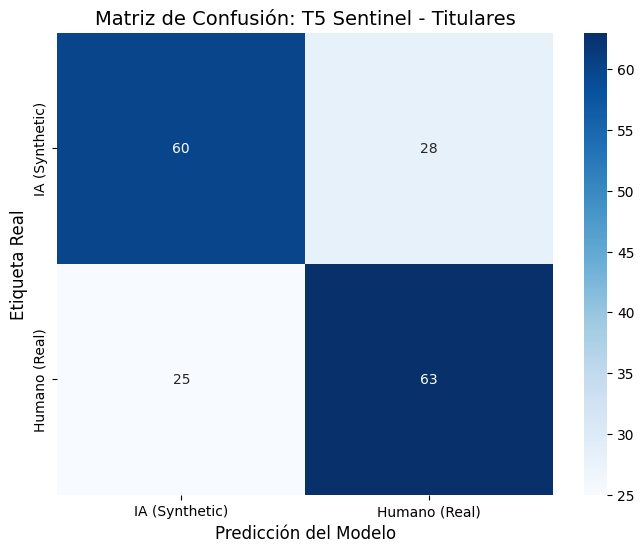

In [14]:
best_config = {
    "lr": 2.1061239900807153e-05,
    "batch_size": 8,
    "grad_acc": 2,
    "weight_decay": 0.1
}

print("Iniciando entrenamiento final con la mejor configuración...")

final_model = T5ForConditionalGeneration.from_pretrained(model_name)
final_data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=final_model)

final_args = TrainingArguments(
    output_dir="./model_final_tfg",
    num_train_epochs=5,
    learning_rate=best_config["lr"],
    per_device_train_batch_size=best_config["batch_size"],
    gradient_accumulation_steps=best_config["grad_acc"],
    weight_decay=best_config["weight_decay"],
    fp16=True,
    report_to="none"
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=tokenized_dataset["train"],
    data_collator=final_data_collator
)

final_trainer.train()

print("\n--- EVALUACIÓN FINAL EN CONJUNTO DE TEST (UNSEEN DATA) ---")
true_labels, mapped_predictions = evaluate_model(final_model, tokenizer, tokenized_dataset["test"])
plot_confusion_matrix(true_labels, mapped_predictions)
